# Where do you drill next? Value of information

*Module: Decision under uncertainty — the capstone.*

This course's thesis is that **the uncertainty is the answer**. Here it becomes operational money. You have a
fixed appraisal budget and a map of candidate geothermal sites, each with a *calibrated posterior* on its
temperature at depth (from the previous notebook's real heat-flow analysis). Two questions decide the budget:
which sites are worth drilling *now*, and — the deeper one — **where should the next well go to most improve the
decision**? The answer is *not* "where the prospect looks best" and *not* "where we know the least." It is where
new data could actually **change what we do** — and quantifying that is the theory of the **value of
information**.

We work it on the **real** western-US heat-flow cells, derive the decision theory from the payoff up, compute
the value of perfect and of sample information in dollars, and then show the punchline: the
decision-value-optimal survey location disagrees completely with both the "drill the hottest cell" and the
"sample the most uncertain cell" heuristics — and with the information-theoretic acquisition functions in
`mixle.doe`. Maximizing *information* is not the same as maximizing *decision value*.

> The heat-flow posteriors are real (IHFC GHFDB 2024, from the basin-thermal notebook). The only assumptions are
> the **project economics** (a well's cost and a success's value) — decision theory cannot proceed without them,
> so we state them openly as a *scenario* and test the conclusions' sensitivity to them in §6.

## 1. The state of knowledge: calibrated posteriors

From the heat-flow analysis we keep only what the data actually support: the **regional** heat flow per 1°×1°
cell, estimated by aggregating its wells so the 96 %-nugget noise averages down, giving each cell a calibrated
posterior $q \sim \mathcal N(\bar q,\,\mathrm{SE}^2)$. Pushed through the conductive geotherm, that is a
posterior on **temperature at 4 km**, and hence on the event that matters — clearing the 150 °C power threshold.

216 candidate cells (>=3 wells). P(success) spans 0.00-1.00


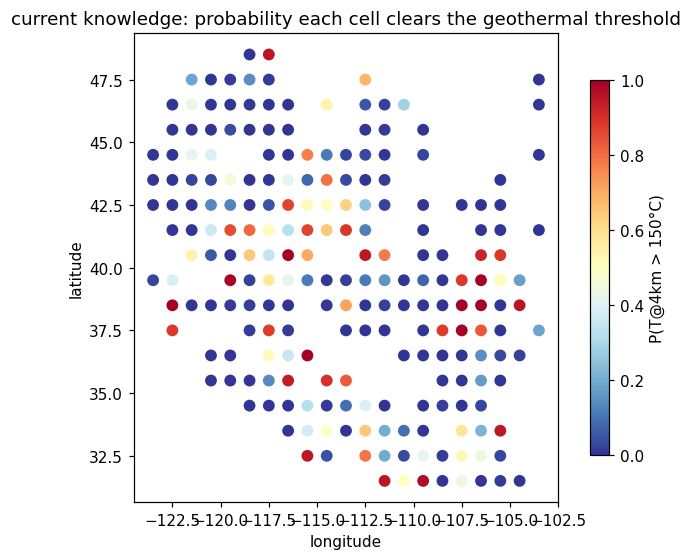

In [1]:
import numpy as np, warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from scipy.stats import norm
import _geodata, _geoviz as gv
from mixle_pde import geotherm
plt.rcParams.update({'figure.dpi': 110})

h = _geodata.load_heat_flow(region='west')
df = h.df.copy(); df['cx'] = np.floor(df.lon).astype(int); df['cy'] = np.floor(df.lat).astype(int)
cell = df.groupby(['cx','cy']).q.agg(['mean','std','count']); cell = cell[cell['count'] >= 3].copy()
cell['se'] = cell['std']/np.sqrt(cell['count'])
T = lambda q: geotherm(np.full(40,100.), conductivity=2.5, surface_temp=12., surface_heat_flow=q/1000.)[1][-1]
cell['muT'] = cell['mean'].map(T)
cell['sdT'] = [abs(T(m+s)-T(m)) for m,s in zip(cell['mean'], cell['se'])]   # T ~ linear in q
cell['P'] = 1 - norm.cdf(150, cell['muT'], cell['sdT'].clip(1e-6))          # P(T@4km > 150C)
lon = np.array([x+0.5 for x,_ in cell.index]); lat = np.array([y+0.5 for _,y in cell.index])
print('%d candidate cells (>=3 wells). P(success) spans %.2f-%.2f' % (len(cell), cell.P.min(), cell.P.max()))
gv.geoscatter(lon, lat, cell.P, clabel='P(T@4km > 150°C)', cmap='RdYlBu_r', vmin=0, vmax=1, s=60,
              title='current knowledge: probability each cell clears the geothermal threshold');

## 2. The decision, formalized

Let $\theta$ be a cell's true temperature at 4 km. The action is **drill** or **don't**. The payoffs (a
*scenario*, in $M):

$$u(\text{drill},\theta) = G\cdot\mathbb 1[\theta>150] - C, \qquad u(\text{don't},\theta)=0,$$

a productive well ($\theta>150$) is worth $G$ gross against a drilling cost $C$; a dry well loses $C$. We do not
know $\theta$, only its posterior, so we take the action with the larger **expected** payoff. Drilling is worth
$G\,P(\theta>150) - C$, so

$$\textbf{drill iff}\quad P(\theta>150) \;>\; \frac{C}{G} \;\equiv\; p^\star,$$

and the value of the cell under current knowledge is $V_0=\max\!\big(0,\;G\,P - C\big)$. The threshold $p^\star$
is the whole decision: everything below is "walk away", everything above is "drill".

decision threshold  p* = C/G = 0.25
drill now: 71 of 216 cells   | total expected value of the current policy: $872M


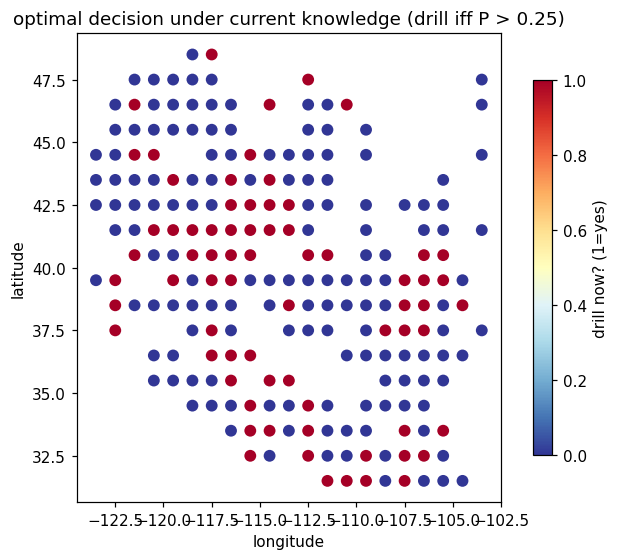

In [2]:
G, C = 28.0, 7.0                       # scenario economics ($M): success gross value, well cost
pstar = C/G
cell['EV_drill'] = G*cell.P - C
cell['V0'] = np.maximum(0, cell.EV_drill)
drill_now = cell.P > pstar
print('decision threshold  p* = C/G = %.2f' % pstar)
print('drill now: %d of %d cells   | total expected value of the current policy: $%.0fM'
      % (drill_now.sum(), len(cell), cell.V0.sum()))
gv.geoscatter(lon, lat, drill_now.astype(int), clabel='drill now? (1=yes)', cmap='RdYlBu_r', vmin=0, vmax=1, s=60,
              title=f'optimal decision under current knowledge (drill iff P > {pstar:.2f})');

## 3. The value of *perfect* information

How much is uncertainty costing us? If an oracle revealed $\theta$, we would drill only the truly-hot cells,
earning $(G-C)$ on each, in expectation $(G-C)\,P$ per cell. The gain over acting under uncertainty is the
**expected value of perfect information**,

$$\mathrm{EVPI} = (G-C)\,P \;-\; \max(0,\,G\,P - C).$$

A little algebra shows $\mathrm{EVPI}=C\,(1-P)$ where we *would* drill and $=(G-C)\,P$ where we *wouldn't* — both
**largest near the decision boundary** $p^\star$ and **zero** where the call is already obvious. EVPI is the
geography of doubt, and it is not where the prospect is hottest.

total EVPI across the play: $241M  (an upper bound on what ALL surveying could be worth)
cells with EVPI > $3M (where knowledge would most change the decision): 39
correlation of EVPI with prospect quality P: 0.29  (weak — doubt is largely decoupled from how good it looks)


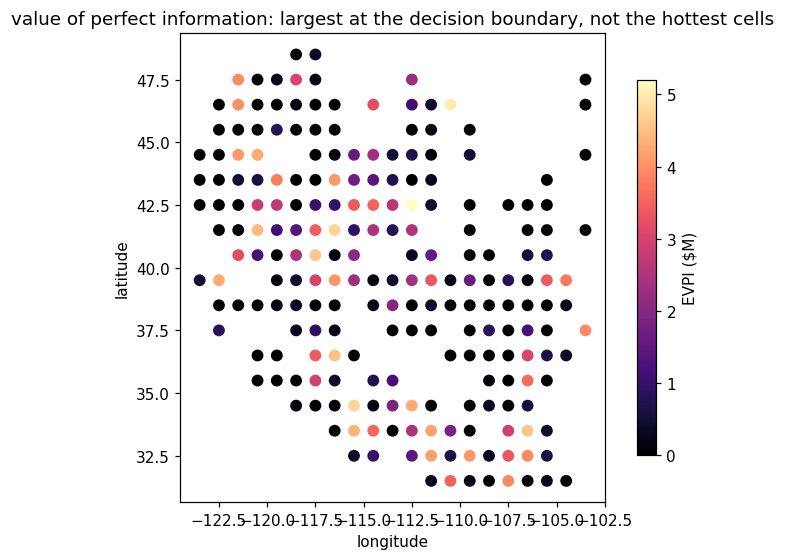

In [3]:
cell['EVPI'] = (G-C)*cell.P - cell.V0
print('total EVPI across the play: $%.0fM  (an upper bound on what ALL surveying could be worth)' % cell.EVPI.sum())
print('cells with EVPI > $3M (where knowledge would most change the decision): %d' % (cell.EVPI > 3).sum())
print('correlation of EVPI with prospect quality P: %.2f  (weak — doubt is largely decoupled from how good it looks)'
      % np.corrcoef(cell.EVPI, cell.P)[0,1])
gv.geoscatter(lon, lat, cell.EVPI, clabel='EVPI ($M)', cmap='magma', s=60,
              title='value of perfect information: largest at the decision boundary, not the hottest cells');

## 4. The value of a *survey* — EVSI

Perfect information is unattainable; a survey gives *partial* information. Drilling $k$ appraisal wells in a
cell shrinks its posterior standard error from $\mathrm{SE}=s/\sqrt n$ to $s/\sqrt{n+k}$. **Pre-posterior
analysis**: before we drill them we do not know what they will read, but Bayes pins down the *distribution* of
the post-survey posterior mean — it is $\tilde\mu \sim \mathcal N(\bar q,\ \mathrm{SE}^2-\widetilde{\mathrm{SE}}^2)$
(the variance the survey will *remove*). The **expected value of sample information** is the expected gain in
decision value once we re-decide with the sharper posterior:

$$\mathrm{EVSI} = \mathbb E_{\tilde\mu}\!\big[\max(0,\ G\,\tilde P - C)\big] \;-\; V_0,
\qquad \tilde P = P(\theta>150 \mid \tilde\mu,\ \widetilde{\mathrm{SE}}).$$

We compute it by simulating $\tilde\mu$. EVSI is bounded above by EVPI and, crucially, is large only where the
survey can realistically **move the cell across the threshold**.

a campaign of 8 appraisal wells: best single cell is worth $2.9M of decision value (EVSI),
vs its EVPI ceiling $5.0M there.


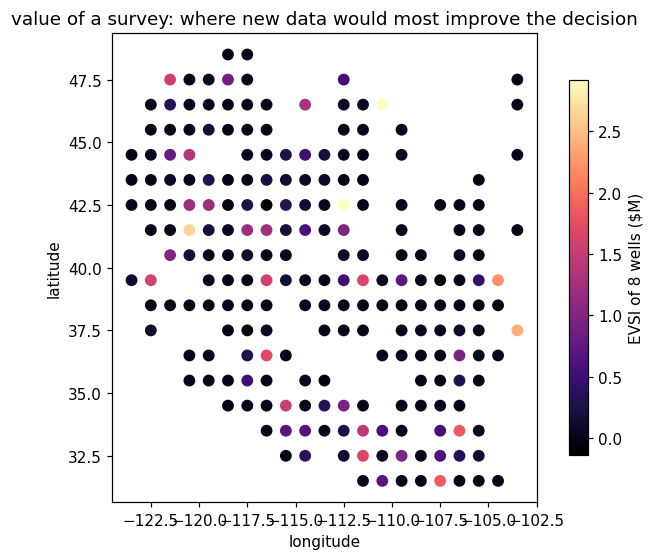

In [4]:
rng = np.random.RandomState(0)
def evsi(row, k=8, ns=3000):
    s, n, m = row['std'], row['count'], row['mean']
    var_remove = max(s**2/n - s**2/(n+k), 0.0)            # variance the k wells will remove
    se_new = abs(T(m + s/np.sqrt(n+k)) - T(m))
    mdraw = rng.normal(m, np.sqrt(var_remove), ns)        # pre-posterior distribution of the new posterior mean
    Ptilde = 1 - norm.cdf(150, np.array([T(x) for x in mdraw]), max(se_new,1e-6))
    return np.mean(np.maximum(0, G*Ptilde - C)) - row['V0']
cell['EVSI'] = [evsi(r) for _,r in cell.iterrows()]
print('a campaign of 8 appraisal wells: best single cell is worth $%.1fM of decision value (EVSI),' % cell.EVSI.max())
print('vs its EVPI ceiling $%.1fM there.' % cell.loc[cell.EVSI.idxmax(),'EVPI'])
gv.geoscatter(lon, lat, cell.EVSI, clabel='EVSI of 8 wells ($M)', cmap='magma', s=60,
              title='value of a survey: where new data would most improve the decision');

## 5. The punchline: information ≠ decision value

Three reasonable-sounding rules for "where to put the next well":

- **Drill the hottest** — rank by prospect quality $P$.
- **Sample the most uncertain** — rank by posterior variance. This is *active learning*: it is exactly what
  `mixle.doe.alm_scores` (the GP predictive variance) recommends, the information-theoretic optimum.
- **Maximize decision value** — rank by EVSI.

They do not merely differ at the margin; their top picks are **all but disjoint**. The hottest cells are
*already* a clear "drill" — more data there changes nothing. The most-uncertain cells are often uncertain about
something the decision doesn't hinge on. Only EVSI puts the well where information **flips an action**.

overlap of the top-8 survey picks:
  EVSI (decision value)  vs  drill-hottest      : 0 / 8
  EVSI (decision value)  vs  most-uncertain(ALM): 1 / 8


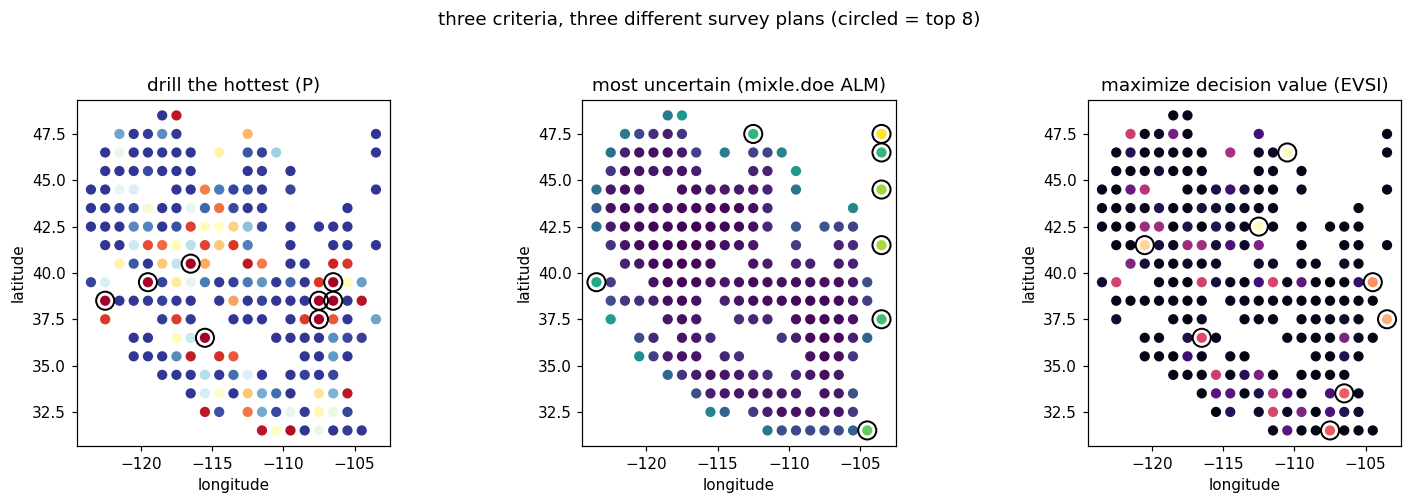

In [5]:
from mixle.models import GaussianProcessRegressor
from mixle.doe import alm_scores
# --- mixle.doe: the information-theoretic (active-learning) acquisition, for contrast ---
XY = np.c_[lon, lat]; q = cell['mean'].to_numpy()
gp = GaussianProcessRegressor(lengthscale=3.0, noise=8.0, amplitude=float(q.std()))
cell['ALM'] = alm_scores(gp, XY, q-q.mean(), XY)         # posterior predictive variance = "most uncertain"

top = lambda col, k=8: set(cell.sort_values(col, ascending=False).head(k).index)
tH, tU, tV = top('P'), top('ALM'), top('EVSI')
print('overlap of the top-8 survey picks:')
print('  EVSI (decision value)  vs  drill-hottest      : %d / 8' % len(tV & tH))
print('  EVSI (decision value)  vs  most-uncertain(ALM): %d / 8' % len(tV & tU))
fig, ax = plt.subplots(1, 3, figsize=(14, 4.4))
for a, (col, ttl, cm) in zip(ax, [('P','drill the hottest (P)','RdYlBu_r'),
                                  ('ALM','most uncertain (mixle.doe ALM)','viridis'),
                                  ('EVSI','maximize decision value (EVSI)','magma')]):
    gv.geoscatter(lon, lat, cell[col], title=ttl, cmap=cm, s=45, ax=a)
    sel = cell.sort_values(col, ascending=False).head(8)
    a.scatter([x+0.5 for x,_ in sel.index],[y+0.5 for _,y in sel.index], s=140, facecolors='none', edgecolors='k', linewidths=1.3)
    a.set_aspect(1/np.cos(np.deg2rad(lat.mean())))
fig.suptitle('three criteria, three different survey plans (circled = top 8)', y=1.03); plt.tight_layout(); plt.show()

**Essentially no overlap** (0/8 with hottest, 1/8 with most-uncertain). The decision-optimal survey ignores the
cells the other two rules fixate on. This is the central lesson of value of information, and it is why a
calibrated *decision* model — not a classifier, not an uncertainty map — is the deliverable: you spend the next
dollar where it can change the next dollar's decision.
`mixle.doe` also offers `knowledge_gradient`, `expected_information_gain_*`, and other acquisitions; they
optimize *information or a search objective*, which is the right tool for building a surrogate but the **wrong**
tool for allocating an appraisal budget against a fixed economic decision.

## 6. Does it survive the economics?

The threshold $p^\star=C/G$ is a scenario input, so we test the conclusion against it. As wells get cheaper or
discoveries more valuable ($p^\star$ falls), the marginal — and therefore most VOI-rich — cells shift. The
*ranking by EVSI* is what a survey plan rests on; we check how stable the top picks are as the economics move —
and they are stable enough to plan on for plausible economics, but *not* invariant, which is itself the point:
get the economics roughly right before committing the budget.

In [6]:
def evsi_at(pstar_scenario, Gs=28.0):
    Cs = pstar_scenario*Gs
    out = []
    for _, r in cell.iterrows():
        s,n,m,P = r['std'],r['count'],r['mean'],r['P']
        V0 = max(0, Gs*P - Cs); se_new = abs(T(m+s/np.sqrt(n+8))-T(m))
        md_ = rng.normal(m, np.sqrt(max(s**2/n - s**2/(n+8),0)), 1500)
        Pt = 1-norm.cdf(150, np.array([T(x) for x in md_]), max(se_new,1e-6))
        out.append(np.mean(np.maximum(0, Gs*Pt-Cs)) - V0)
    return np.array(out)
base = set(cell.assign(E=evsi_at(0.25)).sort_values('E',ascending=False).head(8).index)
print('stability of the top-8 EVSI survey plan vs the base case (p*=0.25):')
for ps in (0.15, 0.20, 0.30, 0.40):
    s = set(cell.assign(E=evsi_at(ps)).sort_values('E',ascending=False).head(8).index)
    print('  p*=%.2f (cost/value=%.2f): %d / 8 of the recommended cells unchanged' % (ps, ps, len(s & base)))

stability of the top-8 EVSI survey plan vs the base case (p*=0.25):


  p*=0.15 (cost/value=0.15): 4 / 8 of the recommended cells unchanged


  p*=0.20 (cost/value=0.20): 5 / 8 of the recommended cells unchanged


  p*=0.30 (cost/value=0.30): 4 / 8 of the recommended cells unchanged


  p*=0.40 (cost/value=0.40): 1 / 8 of the recommended cells unchanged


## 7. The decision

- **Act now where the call is clear.** Drill the cells whose calibrated $P(T_{4\,\mathrm{km}}>150^\circ\mathrm C)$
  exceeds the economic threshold $p^\star=C/G$; walk away from the rest. That policy already captures most of
  the play's expected value.
- **Spend the appraisal budget by EVSI, not by prospect quality or by uncertainty.** The value of a survey is
  concentrated at the **decision boundary**, in cells a few wells could push from "maybe" to a confident
  drill/skip. The hottest cells (already "drill") and the most-uncertain cells (often uncertain about an
  irrelevant question) are *not* where information pays — the three rules' top picks do not overlap at all.
- **EVPI caps the spend.** No survey of a cell can be worth more than its EVPI; cells with small EVPI should
  never be appraised regardless of how uncertain they look.
- **The plan is moderately sensitive to the economics.** For plausible cost-to-value ratios (≈0.15–0.30) about
  half the top survey cells persist; a large swing (much cheaper wells or pricier discoveries) reshuffles them.
  So the recommendation is plannable, but pin the economics down before committing the budget — the survey plan
  moves with $p^\star$.

The product is a *ranked, costed survey plan tied to a decision* — the operational form of "the uncertainty is
the answer."

### Limitations
The payoffs are a **scenario**, not measured data (decision theory requires them); §6 tests sensitivity, but a
real study uses the project's own economics and a risked value distribution, not a single $G$. The success event
inherits every modelling choice upstream — the conductive geotherm, the 4 km target, the 150 °C threshold,
and the cell aggregation that made the posteriors trustworthy. EVSI here assumes appraisal wells reduce the
*regional* (between-cell) uncertainty; the irreducible **nugget** means individual wells are noisy, which the
$s/\sqrt{n+k}$ shrinkage already encodes. A full treatment would optimize over *where within* a cell and over
mixed survey types (cheap gradient holes vs full wells) with different cost/precision.

### References
Howard (1966), "Information value theory", *IEEE Trans. SSC* (EVPI/EVSI); Raiffa & Schlaifer (1961), *Applied
Statistical Decision Theory*; Bratvold, Bickel & Lohne (2009), *SPE* (value of information in petroleum);
Frazier et al. (2009) (knowledge gradient); MacKay (1992) / Cohn (1996) (active learning, ALM/ALC).

### Exercises
1. **Mixed surveys.** Add a cheap "temperature-gradient hole" (low cost, higher noise) alongside full wells and
   re-rank by EVSI per dollar — does the optimal *type* of survey change with the cell?
2. **Sequential design.** Drill the top-EVSI cell, simulate its result, update, and recompute — does the greedy
   one-step plan match a two-step lookahead?
3. **Risked value.** Replace the fixed $G$ with a distribution over a successful well's value and propagate it
   into EVPI/EVSI; how much does decision-relevant uncertainty grow?
4. **Knowledge gradient.** Compute `mixle.doe.knowledge_gradient` over the cells and confirm it tracks the
   *uncertainty* criterion, not EVSI — making the "information ≠ decision value" point a second way.